Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

1. Выгрузка данных из файла.

In [3]:
df = pd.read_csv('D:\\Downloads\\2026-04-28_21-35\\samples.csv', sep=';')

In [4]:
print("Размер данных:", df.shape)
print("Период:", df['Sample Date'].min(), "—", df['Sample Date'].max())
print("Количество станций:", df['GEMS Station Number'].nunique())

Размер данных: (28278, 11)
Период: 1980-01-15 — 2024-12-23
Количество станций: 5


Датасет содержит измерения гидрохимических показателей с 5 станций, находящихся на озере Байкал начиная с 1980 г по 2024й год.

In [5]:
print(df.head())

  GEMS Station Number Sample Date Sample Time  Depth Parameter Code  \
0            RUS00002  2013-11-21       10:20    0.3        Alk-Tot   
1            RUS00002  2013-11-21       10:20    0.3            BOD   
2            RUS00002  2013-11-21       10:20    0.3           NO3N   
3            RUS00002  2013-11-21       10:20    0.3            TDP   
4            RUS00002  2013-11-21       10:20    0.3           NH3N   

  Analysis Method Code Value Flags   Value  Unit Data Quality  Status  
0        Alk-T-D1067-B         NaN  116.00  mg/l          NaN     NaN  
1        BOD-T-COL-AZD         NaN    1.80  mg/l          NaN     NaN  
2           COL-AZO-Cd         NaN    0.17  mg/l          NaN     NaN  
3    COL-AA-SA-APS-PPS         NaN    0.02  mg/l          NaN     NaN  
4              COL-PHE         NaN    0.01  mg/l          NaN     NaN  


In [6]:
df.describe()

,Depth,Value,Status
count,28278.000000,2.827800e+04,0.0
mean,90.182184,8.217192e+02,NaN
std,275.856186,2.973745e+04,NaN
min,0.000000,0.000000e+00,NaN
25%,0.300000,5.000000e-02,NaN
50%,0.300000,4.800000e+00,NaN
75%,50.000000,1.320000e+01,NaN
max,2500.000000,1.930000e+06,NaN


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28278 entries, 0 to 28277
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   GEMS Station Number   28278 non-null  object 
 1   Sample Date           28278 non-null  object 
 2   Sample Time           28278 non-null  object 
 3   Depth                 28278 non-null  float64
 4   Parameter Code        28278 non-null  object 
 5   Analysis Method Code  28278 non-null  object 
 6   Value Flags           1434 non-null   object 
 7   Value                 28278 non-null  float64
 8   Unit                  28278 non-null  object 
 9   Data Quality          25082 non-null  object 
 10  Status                0 non-null      float64
dtypes: float64(3), object(8)
memory usage: 2.4+ MB


In [7]:
df.head(10)

,GEMS Station Number,Sample Date,Sample Time,Depth,Parameter Code,Analysis Method Code,Value Flags,Value,Unit,Data Quality,Status
0,RUS00002,2013-11-21,10:20,0.3,Alk-Tot,Alk-T-D1067-B,NaN,116.00,mg/l,NaN,NaN
1,RUS00002,2013-11-21,10:20,0.3,BOD,BOD-T-COL-AZD,NaN,1.80,mg/l,NaN,NaN
2,RUS00002,2013-11-21,10:20,0.3,NO3N,COL-AZO-Cd,NaN,0.17,mg/l,NaN,NaN
3,RUS00002,2013-11-21,10:20,0.3,TDP,COL-AA-SA-APS-PPS,NaN,0.02,mg/l,NaN,NaN
4,RUS00002,2013-11-21,10:20,0.3,NH3N,COL-PHE,NaN,0.01,mg/l,NaN,NaN
5,RUS00002,2013-11-21,10:20,0.3,Fe-Dis,COL-TPTZ-DIS,NaN,0.07,mg/l,NaN,NaN
6,RUS00002,2013-11-21,10:20,0.3,SiO2-Rea,COL-HB,NaN,4.90,mg/l,NaN,NaN
7,RUS00002,2013-11-21,10:20,0.3,EC,EC-CND-Pt,NaN,200.00,µS/cm,NaN,NaN
8,RUS00002,2013-11-21,10:20,0.3,TSS,TSS-G,NaN,21.00,mg/l,NaN,NaN
9,RUS00002,2013-11-21,10:20,0.3,Mg-Dis,Mg-CALC-H-Ca,NaN,7.40,mg/l,NaN,NaN


In [8]:
df.drop(columns=['Status'], inplace=True)

Перевернем данные так, чтобы экологические параметры оказались в формате столбцов. Усредним по дате измерения, чтобы избежать большое количество пропусков в строках. 

In [9]:
df['Sample Date'] = pd.to_datetime(df['Sample Date'], errors='coerce')

df_pivot = df.pivot_table(
    index=[pd.Grouper(key='Sample Date', freq='ME'), 'GEMS Station Number'],
    columns='Parameter Code',
    values='Value',
    aggfunc='mean'
).reset_index()

In [10]:
df_pivot.head(10)

Parameter Code,Sample Date,GEMS Station Number,Alk-Tot,BOD,Ca-Dis,Cl-Dis,EC,Fe-Dis,Hg-Dis,K-Dis,...,O2-Dis,Pb-Dis,Q-Inst,SO4-Dis,SiO2-Rea,TDP,TEMP,TSS,Zn-Dis,pH
0,1980-01-31,RUS00002,134.85,0.170000,32.86,5.7,NaN,0.13,NaN,NaN,...,8.220000,NaN,82.200000,17.0,6.1,0.045,0.0,2.8,NaN,7.50
1,1980-02-29,RUS00002,133.02,0.660000,32.26,5.1,NaN,0.99,NaN,NaN,...,6.320000,NaN,49.800000,22.8,9.1,0.125,0.0,NaN,NaN,7.45
2,1980-03-31,RUS00002,134.24,NaN,31.66,5.3,NaN,0.28,NaN,NaN,...,8.520000,NaN,54.100000,18.0,5.2,0.056,0.0,16.2,0.0100,7.40
3,1980-04-30,RUS00002,125.09,1.930000,31.86,4.0,NaN,0.50,NaN,0.8,...,12.600000,NaN,203.500000,12.6,1.0,0.020,0.0,4.2,NaN,7.45
4,1980-05-31,RUS00002,58.57,NaN,17.83,2.6,NaN,0.42,NaN,1.6,...,10.373333,NaN,1806.666667,9.9,4.5,0.022,9.4,1.4,NaN,7.35
5,1980-06-30,RUS00002,NaN,1.930000,NaN,NaN,NaN,NaN,NaN,NaN,...,8.710000,NaN,1057.000000,NaN,NaN,NaN,20.0,11.4,0.0145,7.40
6,1980-07-31,RUS00002,NaN,1.026667,NaN,2.1,NaN,0.22,NaN,NaN,...,8.450000,NaN,882.200000,13.6,NaN,NaN,NaN,NaN,NaN,NaN
7,1980-08-31,RUS00002,84.20,0.830000,22.24,2.1,NaN,0.78,NaN,0.8,...,8.655000,NaN,921.500000,12.4,0.3,0.260,22.7,5.2,0.0140,7.45
8,1980-09-30,RUS00002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,10.400000,NaN,705.666667,NaN,NaN,NaN,8.6,17.0,0.0100,7.25
9,1980-10-31,RUS00002,104.34,1.630000,25.04,2.1,NaN,0.16,NaN,1.2,...,12.730000,NaN,579.400000,12.4,5.1,0.000,0.0,30.8,NaN,7.47


In [10]:
df_pivot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 742 entries, 0 to 741
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Sample Date          742 non-null    datetime64[ns]
 1   GEMS Station Number  742 non-null    object        
 2   Alk-Tot              547 non-null    float64       
 3   BOD                  661 non-null    float64       
 4   Ca-Dis               552 non-null    float64       
 5   Cl-Dis               684 non-null    float64       
 6   EC                   670 non-null    float64       
 7   Fe-Dis               504 non-null    float64       
 8   Hg-Dis               208 non-null    float64       
 9   K-Dis                129 non-null    float64       
 10  Mg-Dis               557 non-null    float64       
 11  NH3N                 685 non-null    float64       
 12  NO3N                 672 non-null    float64       
 13  Na-Dis               130 non-null  

2. Рассмотрим количество пропусков. В реализации рассчитала доли незаполненных значений для каждого столбца и построила столбчатую диаграмму. 

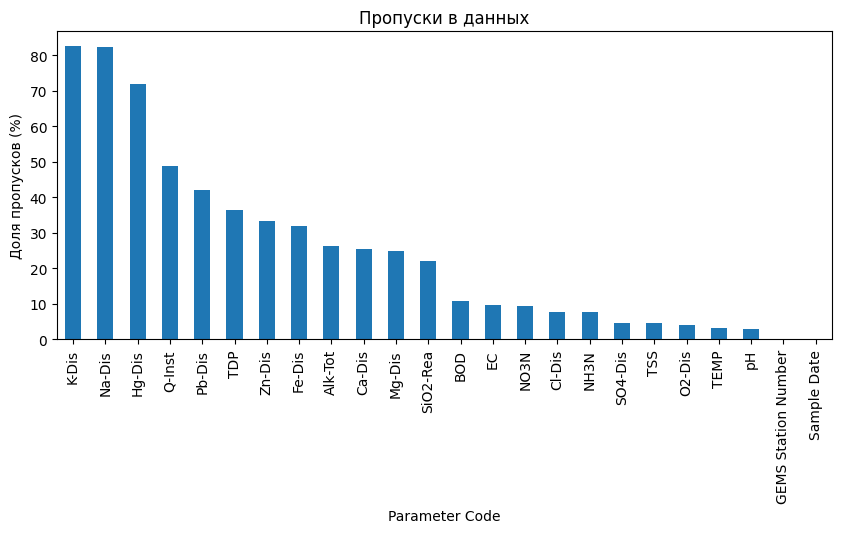

In [11]:
# Доля пропусков по каждому параметру
missing = df_pivot.isnull().mean() * 100
missing_sorted = missing.sort_values(ascending=False)

import matplotlib.pyplot as plt
missing_sorted.plot(kind='bar', figsize=(10,4))
plt.ylabel('Доля пропусков (%)')
plt.title('Пропуски в данных')
plt.show()

Для исследования пропусков также можно использовать библиотеку missingno. В таком случае можно посмотреть долю заполненности для каждого столбца.

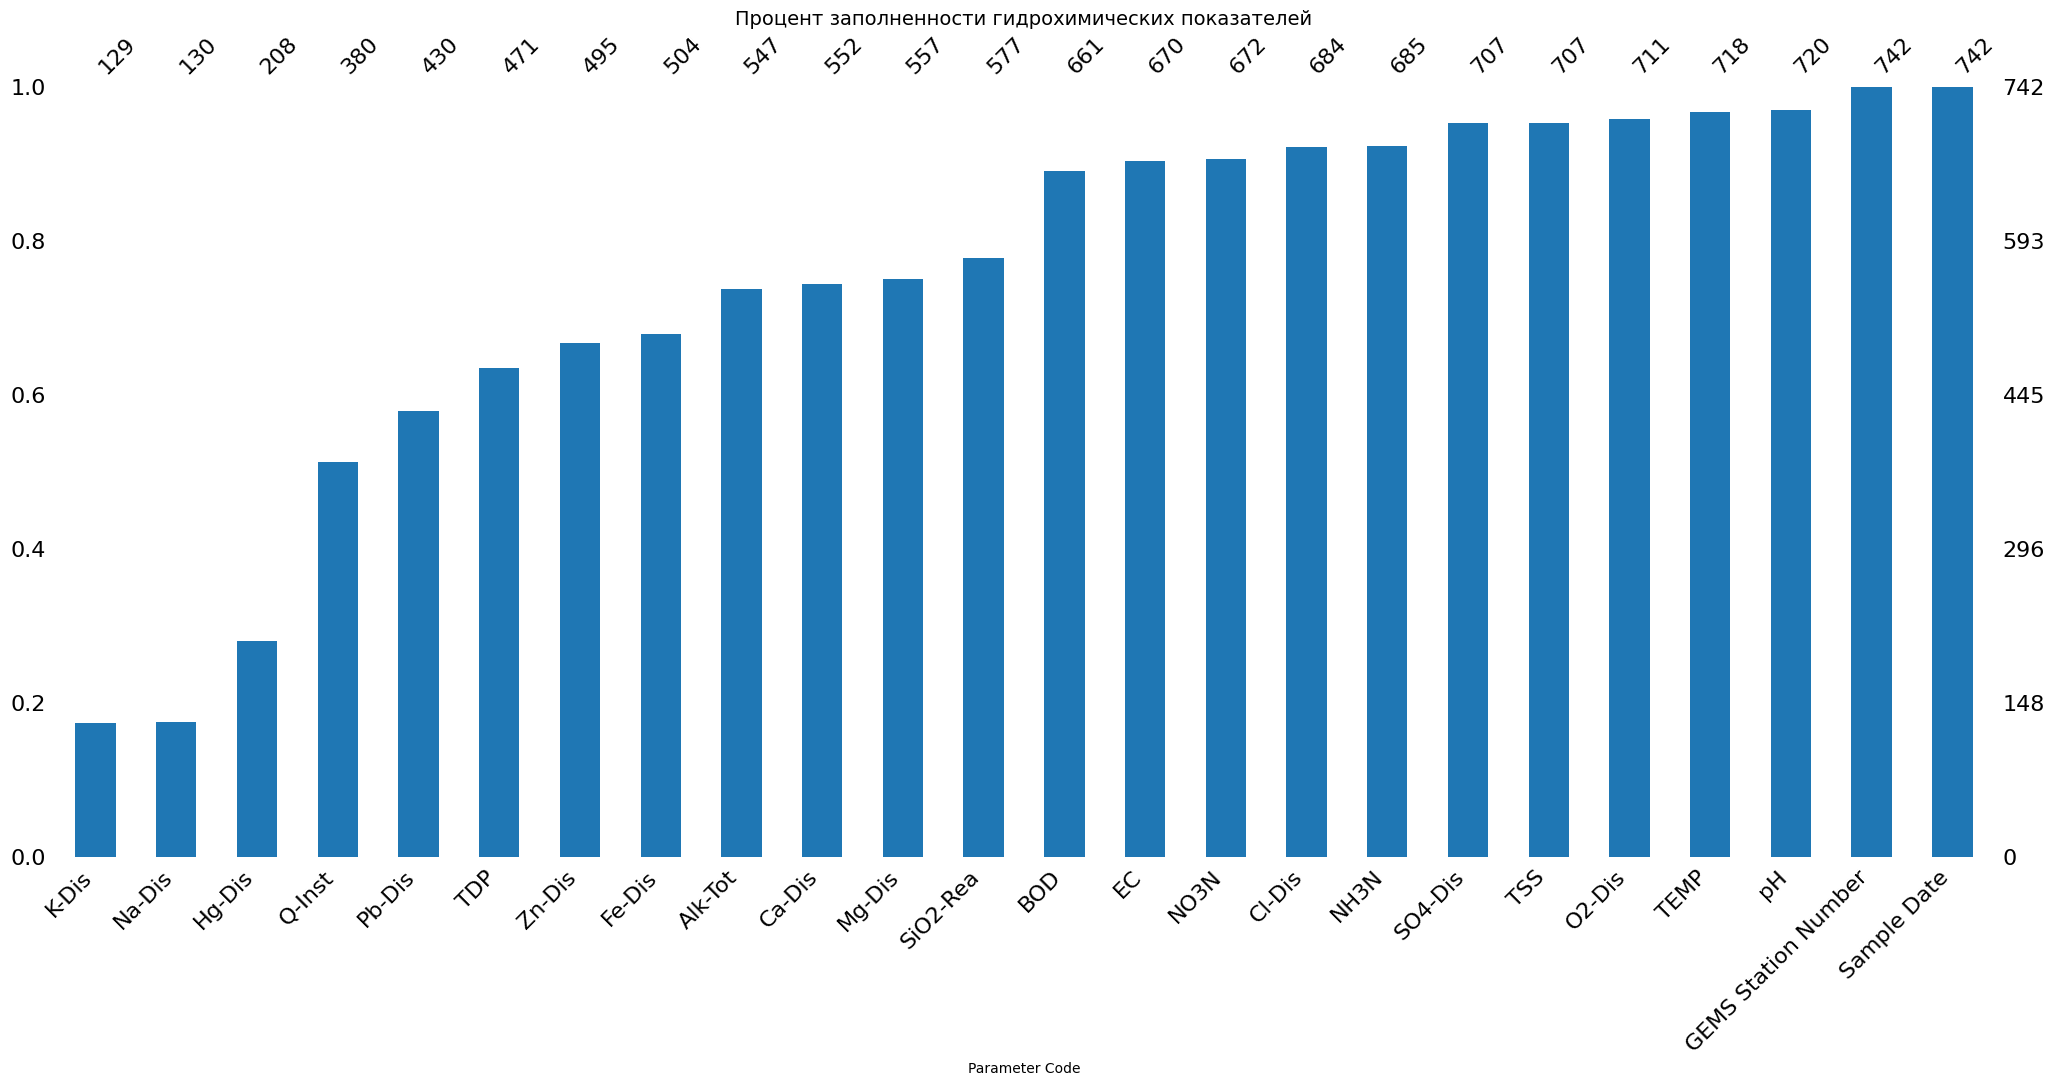

In [12]:
import missingno as msno

# 1. Столбчатая диаграмма полноты данных
plt.figure(figsize=(10, 5))
msno.bar(df_pivot, color="C0", sort = 'ascending')
plt.title('Процент заполненности гидрохимических показателей', fontsize=14)
plt.show()

В данном датасете наибольшее количество пропусков у Калия, Натрия и ртути.

In [11]:
df_pivot.describe()

Parameter Code,Sample Date,Alk-Tot,BOD,Ca-Dis,Cl-Dis,EC,Fe-Dis,Hg-Dis,K-Dis,Mg-Dis,...,O2-Dis,Pb-Dis,Q-Inst,SO4-Dis,SiO2-Rea,TDP,TEMP,TSS,Zn-Dis,pH
count,742,547.000000,661.000000,552.000000,684.000000,6.700000e+02,504.000000,208.000000,129.000000,557.000000,...,711.000000,430.000000,380.000000,707.000000,577.000000,471.000000,718.000000,707.000000,495.000000,720.000000
mean,2001-09-24 06:35:54.177897600,78.083862,1.392888,18.433944,1.820648,7.640533e+03,0.287526,0.048926,1.127132,5.036052,...,10.180626,0.002064,909.060042,11.991869,2.973517,0.035773,6.733405,12.506918,0.022888,7.674885
min,1980-01-31 00:00:00,45.320000,0.000000,7.600000,0.400000,0.000000e+00,0.000000,0.000000,0.000000,1.500000,...,5.586667,0.000000,38.266667,4.400000,0.100000,0.000000,0.000000,0.000000,0.000000,6.866667
25%,1988-03-31 00:00:00,62.200000,0.950000,14.600000,0.740000,1.000000e-04,0.019000,0.020000,0.800000,3.500000,...,9.000000,0.000000,189.916667,5.980000,0.700000,0.009500,0.037500,1.420000,0.001000,7.466667
50%,1999-05-15 12:00:00,65.500000,1.380000,16.048333,1.600000,2.000000e-04,0.080000,0.050000,1.100000,5.000000,...,10.345000,0.000650,635.560606,11.500000,1.100000,0.020000,4.600000,2.000000,0.004200,7.680000
75%,2016-12-23 06:00:00,92.725000,1.750000,22.800000,2.600000,2.000000e+02,0.340000,0.050000,1.400000,6.300000,...,11.370833,0.004000,1416.666667,17.100000,5.300000,0.024000,11.262500,11.733333,0.009100,7.866667
max,2024-12-31 00:00:00,145.000000,5.710000,36.060000,7.800000,1.379500e+06,7.850000,0.260000,2.400000,10.600000,...,15.530000,0.031400,4153.333333,34.000000,11.300000,1.940000,22.700000,270.000000,5.900000,8.500000
std,NaN,21.862400,0.648350,6.143255,1.247266,9.571876e+04,0.551102,0.043199,0.396075,1.652030,...,1.581504,0.003009,868.418677,6.350651,2.626950,0.164588,6.517858,25.347516,0.282865,0.288681


Температура колеблется от 0°C до 9.4°C, среднее значение составляет около 0.5°C.

Кислород находится в диапазоне от 5.6 до 15.5 мг/л, среднее — 10.2 мг/л.

Электропроводность (EC) показывает значительный разброс: от 0 до 1 379 500, что может указывать на аномально высокие значения. Средние значения электропроводности для пресной воды должны находиться в диапазоне от 100 до 2000 мкСМ/см, в данном случае наблюдается ошибка измерений. 
Щёлочность (Alk-Tot) варьируется от 45 до 145 мг/л, среднее — 78 мг/л.
БПК (BOD) в среднем составляет 1.4 мг/л, что говорит о низком уровне органического загрязнения.

Тяжёлые металлы (Pb, Hg) присутствуют в очень малых концентрациях.

3. Рассмотрим корелляции параметров

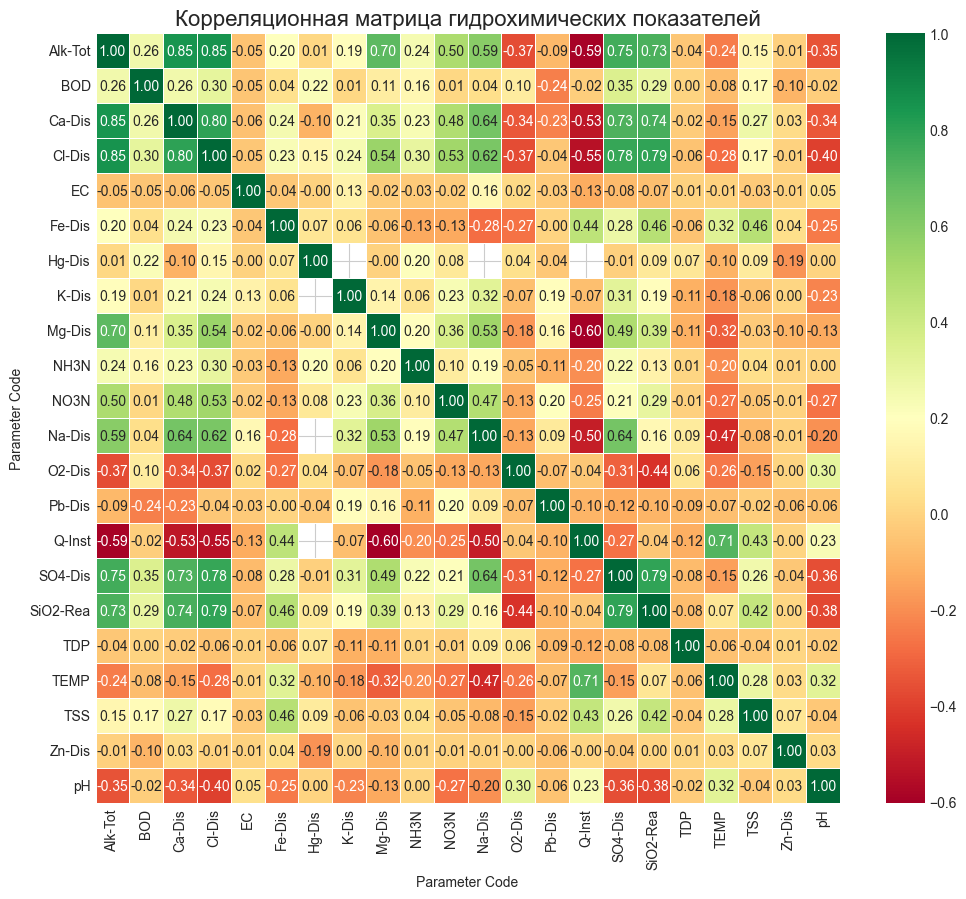

In [32]:

numeric_df = df_pivot.select_dtypes(include=['number'])

# 2. Рассчитываем корреляцию только для чисел
corr_matrix = numeric_df.corr()

# 3. Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица гидрохимических показателей', fontsize=16)
plt.show()

Можно увидеть отрицательную корелляцию между параметрами Q-inst и хлоридами, кальцием, магнием и щелочностью. Q-Inst -- это показатель, отвечающий за мгновенный расход воды. Самая сильная отрицательная корелляция между расходом и магнием. 
Согласно источникам, мгновенный расход воды зависит от сезона, тк на его значение влияют талые воды и период дождей. С увеличением расхода воды концентрация веществ падает.
Построим точечный график для проверки. 

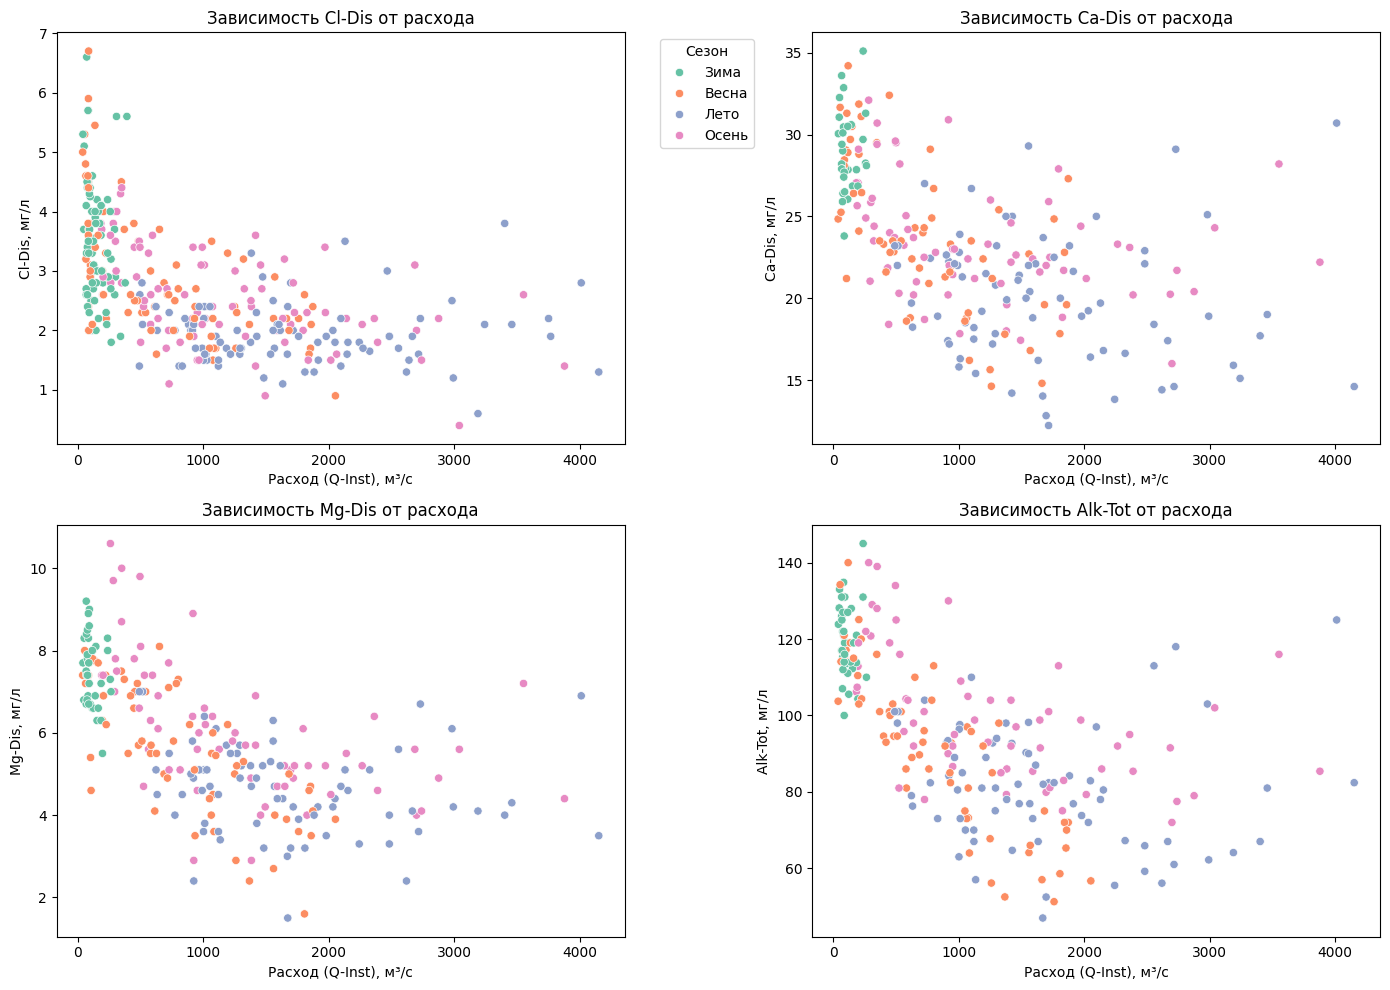

In [22]:

def get_season(month):
    if month in [12, 1, 2]:
        return 'Зима'
    elif month in [3, 4, 5]:
        return 'Весна'
    elif month in [6, 7, 8]:
        return 'Лето'
    else:
        return 'Осень'

df_pivot['Season'] = df_pivot['Sample Date'].dt.month.apply(get_season)

params = ['Cl-Dis', 'Ca-Dis', 'Mg-Dis', 'Alk-Tot']

# Создаём фигуру с 2 строками и 2 столбцами (4 графика)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()  # превращаем матрицу в одномерный массив для удобства

# Для каждого параметра строим scatterplot
for i, param in enumerate(params):
    sns.scatterplot(
        data=df_pivot,
        x='Q-Inst',
        y=param,
        hue='Season',          # цвет по сезону
        palette='Set2',
        ax=axes[i]
    )
    axes[i].set_title(f'Зависимость {param} от расхода')
    axes[i].set_xlabel('Расход (Q-Inst), м³/с')
    axes[i].set_ylabel(f'{param}, мг/л')
    if i == 0:
        axes[i].legend(title='Сезон', bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        axes[i].legend().remove()  # легенду оставляем только на первом графике

plt.tight_layout()
plt.show()

Действительно, высокая концентрация параметров в зимний период выше всего, тк мгноменный расход воды низкий. В первые весенние месяцы в данном регионен сохраняется ледяной покров, поэтому концентрация в этот период также высокая
Далее исследуем среднегодичную 

In [55]:
n = 11
max_date = df_pivot['Sample Date'].max()
start_date = max_date - pd.DateOffset(years=n)
df_recent = df_pivot[df_pivot['Sample Date'] >= start_date].copy()

Для удобства будем использовать данные не за весь период, а за последние n лет. Рассмотрим в разрезе одной станции.

In [72]:
print(df_pivot['GEMS Station Number'].unique())

['RUS00002' 'RUS00021' 'RUS00022' 'RUS00024' 'RUS00023']


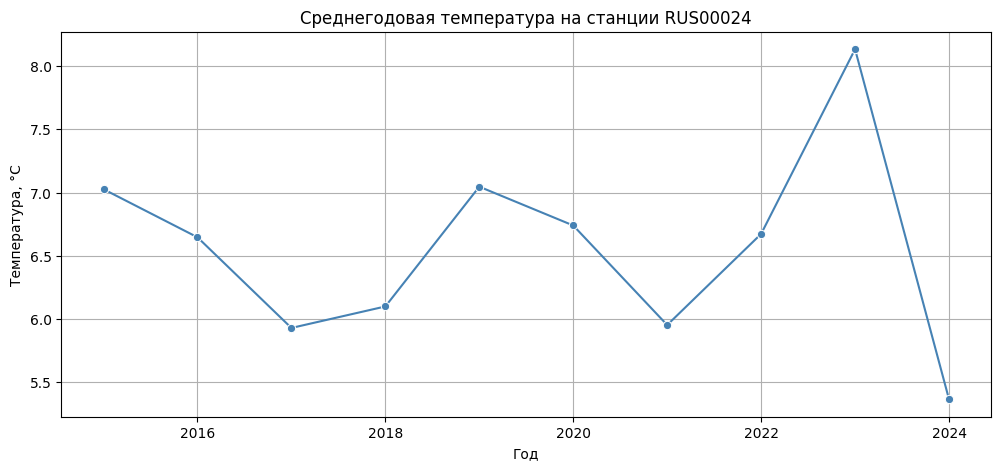

In [56]:
station_code = 'RUS00024'
df_recent['Year'] = df_recent['Sample Date'].dt.year
df_station = df_recent[df_recent['GEMS Station Number'] == station_code].copy()
annual_temp = df_station.groupby('Year', as_index=False)['TEMP'].mean()

plt.figure(figsize=(12, 5))
sns.lineplot(data=annual_temp, x='Year', y='TEMP', marker='o', color='steelblue')
plt.title(f'Среднегодовая температура на станции {station_code}')
plt.xlabel('Год')
plt.ylabel('Температура, °C')
plt.grid(True)
plt.show()


В период с 2014го по 2024й годы визуально тренд не наблюдается, температура стабильно колеблется от 9,5 до 4х градусов в разные годы. 

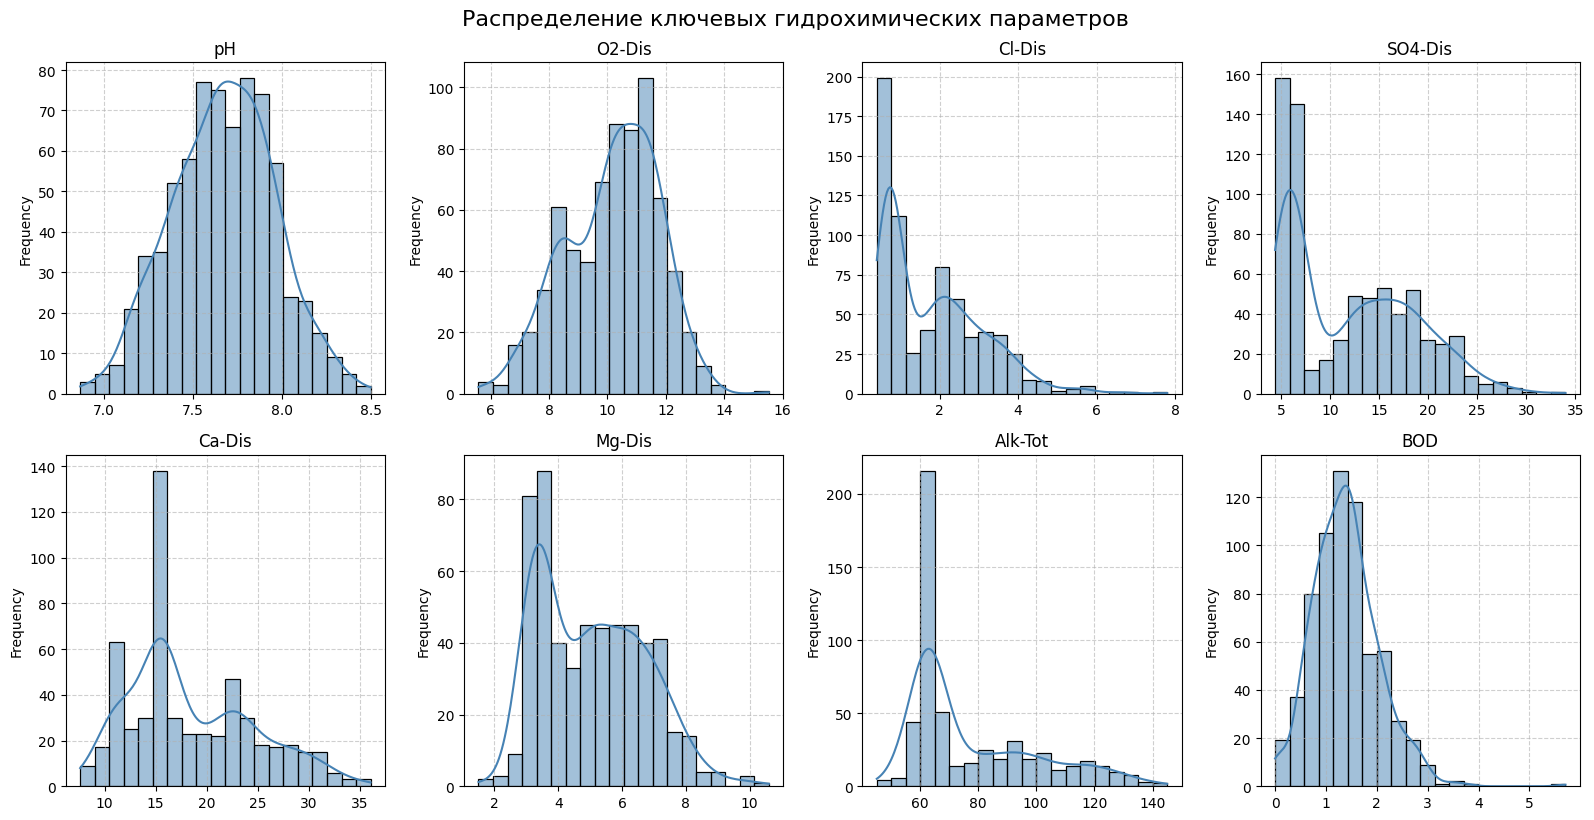

In [60]:
important_params = [
    'pH', 'O2-Dis',          
    'Cl-Dis', 'SO4-Dis', 'Ca-Dis', 'Mg-Dis', 'Alk-Tot',  
    'BOD'           
]
cols_to_plot = [c for c in important_params if c in df_pivot.columns]
n_cols = 4  # 4 столбца для удобства
n_rows = (len(cols_to_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()
for i, col in enumerate(cols_to_plot):
    # Убираем NaN для красивого графика
    data = df_pivot[col].dropna()
    
    if len(data) > 0:
        sns.histplot(data, bins=20, kde=True, ax=axes[i], color='steelblue')
        axes[i].set_title(f'{col}', fontsize=12)
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, linestyle='--', alpha=0.6)

# Удаляем пустые подграфики
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Распределение ключевых гидрохимических параметров', y=1.02, fontsize=16)
plt.show()

Согласно графикам, ph визуально распределен нормально, а большинство параметров имеют скошенное вправо распределение. Это в основном говорит о низких концентрациях веществ  в пресной воде. Минерализация (Cl, SO4, Ca, Mg)  в пределах нормы. Параметр BOD (биологическое потребление кислорода) принимает низкие значения, что говорит о низкой загрязненности.